In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════════
COMPLETE DEMO: AFib Detection Model Training Pipeline
═══════════════════════════════════════════════════════════════════════════════

This notebook demonstrates the COMPLETE workflow:
    1. Data loading and exploration
    2. Research-accurate preprocessing
    3. Model training (all 5 models)
    4. Results analysis and comparison

MODELS TRAINED:
    • CNN-BiLSTM (Andersen 2019)
    • CNN-LSTM-Focal (Petmezas 2021)
    • AFib-ResLSTM (Novel)
    • ResNet-BiLSTM-Attention (Jia 2020)
    • Lightweight-ResNet (Lueken 2025)
═══════════════════════════════════════════════════════════════════════════════
"""

In [2]:
#Setup and Imports

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

In [3]:
BASE_PATH = Path("/storage/scratch2/e20-fyp-atfib-det").resolve()

# Verify path exists
if not BASE_PATH.exists():
    raise FileNotFoundError(
        f"Base path not found: {BASE_PATH}\n"
        f"Please update BASE_PATH to match your system!"
    )

In [4]:
CODES_PATH = BASE_PATH / "codes"
MODEL_FOLDER_PATH = BASE_PATH / "modelFolder"

sys.path.append(str(BASE_PATH))
sys.path.append(str(CODES_PATH))
sys.path.append(str(MODEL_FOLDER_PATH))

print(f"{'═'*80}")
print(f"{'PROJECT PATHS CONFIGURED':^80}")
print(f"{'═'*80}")
print(f"Base Path:        {BASE_PATH}")
print(f"Codes Path:       {CODES_PATH}")
print(f"Model Path:       {MODEL_FOLDER_PATH}")
print(f"\n System Info:")
print(f"   Python:           {sys.version.split()[0]}")
print(f"   PyTorch:          {torch.__version__}")
print(f"   CUDA Available:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   CUDA Device:      {torch.cuda.get_device_name(0)}")
print(f"{'═'*80}\n")

════════════════════════════════════════════════════════════════════════════════
                            PROJECT PATHS CONFIGURED                            
════════════════════════════════════════════════════════════════════════════════
Base Path:        /storage/scratch2/e20-fyp-atfib-det
Codes Path:       /storage/scratch2/e20-fyp-atfib-det/codes
Model Path:       /storage/scratch2/e20-fyp-atfib-det/modelFolder

 System Info:
   Python:           3.12.12
   PyTorch:          2.6.0
   CUDA Available:   True
   CUDA Device:      NVIDIA RTX A6000
════════════════════════════════════════════════════════════════════════════════



SECTION 2: LOAD RAW DATA

In [5]:
from universal_loader import UniversalECGLoader
# ───────────────────────────────────────────────────────────────────────────
# Define data paths
# ───────────────────────────────────────────────────────────────────────────
AFDB_PATH = BASE_PATH / "data" / "raw" / "mit-bih-afdb"
CINC_PATH = BASE_PATH / "data" / "raw" / "physionet-challenge-2017"

print(f"\n{'═'*80}")
print(f"LOADING RAW ECG DATA")
print(f"{'═'*80}\n")


 EXPLORING: MIT-BIH Atrial Fibrillation Database (AFDB)

ANALYZING DATASET AT: ../data/raw/mit-bih-afdb

📁 Directory Structure:
   Root: ../data/raw/mit-bih-afdb
   Subdirectories: old

📄 File Types Found:
   .atr: 50 files
   .atr-: 2 files
   .dat: 23 files
   .hea: 25 files
   .hea-: 23 files
   .qrs: 25 files
   .qrs-: 1 files
   .qrsc: 2 files
   .txt: 2 files
   .xws: 1 files

📊 Metadata Files:
   - notes.txt
   - SHA256SUMS.txt

🔍 Detected Format: WFDB
   Total record files: 23


✅ Found 25 records in WFDB format

🔍 Validating 25 records...
   Progress: 10/25 (8 valid)
   Progress: 20/25 (18 valid)

✅ Found 23 valid records
⚠️  Skipped 2 problematic records:
   • 00735: Failed to load record '00735': Error reading WFDB file: samp...
   • 03665: Failed to load record '03665': Error reading WFDB file: samp...

--- Loading a single sample record from AFDB ---
Signal shape: (9205760, 2)
Sampling rate: 250 Hz
Channels: ['ECG1', 'ECG2']

📊 Analyzing dataset characteristics...
✅ Found

In [6]:
# ───────────────────────────────────────────────────────────────────────────
# Load MIT-BIH Atrial Fibrillation Database
# ───────────────────────────────────────────────────────────────────────────
print(f"Loading MIT-BIH AFDB from: {AFDB_PATH}")
afdb_loader = UniversalECGLoader(str(AFDB_PATH))
afdb_records = afdb_loader.get_valid_records()
print(f"Found {len(afdb_records)} valid AFDB records\n")

Loading MIT-BIH AFDB from: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih-afdb

ANALYZING DATASET AT: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih-afdb

📁 Directory Structure:
   Root: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih-afdb
   Subdirectories: old

📄 File Types Found:
   .atr: 50 files
   .atr-: 2 files
   .dat: 23 files
   .hea: 25 files
   .hea-: 23 files
   .qrs: 25 files
   .qrs-: 1 files
   .qrsc: 2 files
   .txt: 2 files
   .xws: 1 files

📊 Metadata Files:
   - notes.txt
   - SHA256SUMS.txt

🔍 Detected Format: WFDB
   Total record files: 23


✅ Found 25 records in WFDB format

🔍 Validating 25 records...
   Progress: 10/25 (8 valid)
   Progress: 20/25 (18 valid)

✅ Found 23 valid records
⚠️  Skipped 2 problematic records:
   • 00735: Failed to load record '00735': Error reading WFDB file: samp...
   • 03665: Failed to load record '03665': Error reading WFDB file: samp...
Found 23 valid AFDB records



In [7]:
# ───────────────────────────────────────────────────────────────────────────
# Load PhysioNet Challenge 2017 Database
# ───────────────────────────────────────────────────────────────────────────
print(f"Loading PhysioNet 2017 from: {CINC_PATH}")
cinc_loader = UniversalECGLoader(str(CINC_PATH))
cinc_records = cinc_loader.get_valid_records()
print(f"Found {len(cinc_records)} valid CINC records\n")

print(f"{'═'*80}\n")

Loading PhysioNet 2017 from: /storage/scratch2/e20-fyp-atfib-det/data/raw/physionet-challenge-2017

ANALYZING DATASET AT: /storage/scratch2/e20-fyp-atfib-det/data/raw/physionet-challenge-2017



📁 Directory Structure:
   Root: /storage/scratch2/e20-fyp-atfib-det/data/raw/physionet-challenge-2017
   Subdirectories: training, sources

📄 File Types Found:
   .css: 1 files
   .csv: 8 files
   .gz: 2 files
   .hea: 4296 files
   .m: 9 files
   .mat: 4296 files
   .pdf: 2 files
   .py: 1 files
   .sh: 6 files
   .svg: 1 files
   .txt: 9 files
   .xls: 1 files
   .zip: 69 files

📊 Metadata Files:
   - REFERENCE-v2.csv
   - followup-combined-sorted-with-ranking-median-95thpc.csv
   - results_all_F1_scores_for_each_classification_type.csv
   - REFERENCE-v0.csv
   - results.csv
   ... and 12 more

🔍 Detected Format: MATLAB
   Total record files: 4296


✅ Found 4296 records in MATLAB format

🔍 Validating 4296 records...
   Progress: 10/4296 (10 valid)
   Progress: 20/4296 (20 valid)
   Progress: 30/4296 (30 valid)
   Progress: 40/4296 (40 valid)
   Progress: 50/4296 (50 valid)
   Progress: 60/4296 (60 valid)
   Progress: 70/4296 (70 valid)
   Progress: 80/4296 (80 valid)
   Progress: 90/


════════════════════════════════════════════════════════════════════════════════
SAMPLE RECORD INSPECTION
════════════════════════════════════════════════════════════════════════════════

📊 Record: 04015
────────────────────────────────────────────────────────────────────────────────
   Signal Shape:    (9205760, 2)
   Sampling Rate:   250 Hz
   Duration:        36823.04 seconds
   Channels:        ['ECG1', 'ECG2']
   Format:          WFDB


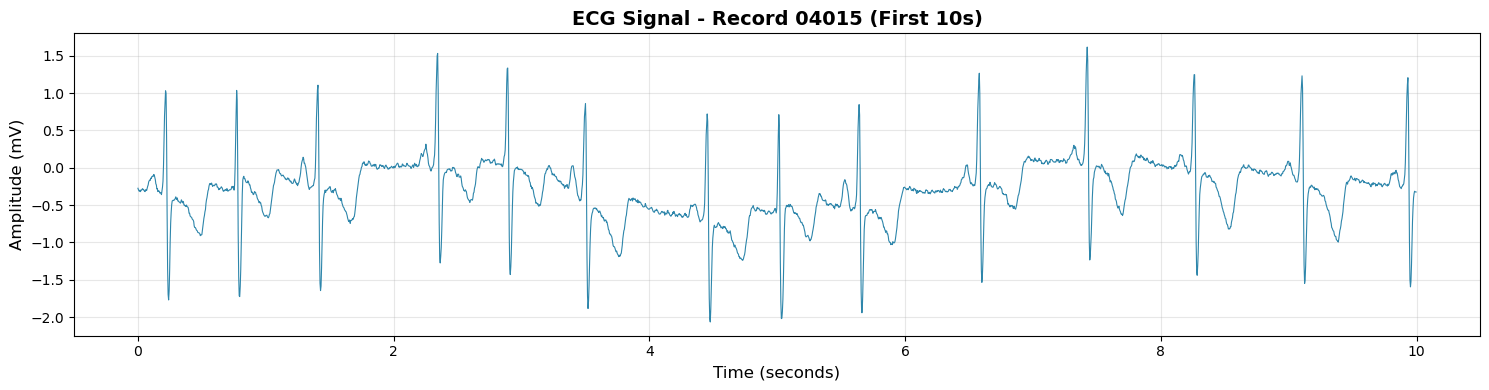


════════════════════════════════════════════════════════════════════════════════



In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3: EXPLORE A SAMPLE RECORD
# ═══════════════════════════════════════════════════════════════════════════

if afdb_records:
    print(f"\n{'═'*80}")
    print(f"SAMPLE RECORD INSPECTION")
    print(f"{'═'*80}\n")
    
    # Load first record
    sample_record = afdb_records[0]
    data = afdb_loader.load_record(sample_record)
    
    print(f"📊 Record: {sample_record}")
    print(f"{'─'*80}")
    print(f"   Signal Shape:    {data['signal'].shape}")
    print(f"   Sampling Rate:   {data['fs']} Hz")
    print(f"   Duration:        {data['duration']:.2f} seconds")
    print(f"   Channels:        {data['channels']}")
    print(f"   Format:          {data['format']}")
    
    # ───────────────────────────────────────────────────────────────────────
    # Visualize ECG signal
    # ───────────────────────────────────────────────────────────────────────
    plt.figure(figsize=(15, 4))
    
    # Plot first 10 seconds of first channel
    duration_to_plot = 10  # seconds
    samples_to_plot = int(duration_to_plot * data['fs'])
    signal = data['signal'][:samples_to_plot, 0]
    time = np.arange(len(signal)) / data['fs']
    
    plt.plot(time, signal, linewidth=0.8, color='#2E86AB')
    plt.title(f'ECG Signal - Record {sample_record} (First {duration_to_plot}s)', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Amplitude (mV)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'═'*80}\n")

 Preprocessing for Models

Part 2: Research-Accurate Preprocessing

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4: INITIALIZE PREPROCESSOR
# ═══════════════════════════════════════════════════════════════════════════

from research_accurate_preprocessor import ResearchAccuratePreprocessor

# ───────────────────────────────────────────────────────────────────────────
# Define paths
# ───────────────────────────────────────────────────────────────────────────
PROCESSED_DATA_PATH = BASE_PATH / "data" / "processed"
CINC_REFERENCE_CSV = CINC_PATH / "REFERENCE-v3.csv"

print(f"\n{'═'*80}")
print(f"INITIALIZING RESEARCH-ACCURATE PREPROCESSOR")
print(f"{'═'*80}\n")

# ───────────────────────────────────────────────────────────────────────────
# Create preprocessor instance
# ───────────────────────────────────────────────────────────────────────────
preprocessor = ResearchAccuratePreprocessor(
    raw_data_paths=[
        str(AFDB_PATH),
        str(CINC_PATH)
    ],
    cinc_reference_path=str(CINC_REFERENCE_CSV),
    output_dir=str(PROCESSED_DATA_PATH),
    lead_to_use='MLII',  # Standard lead for AFib detection
    random_seed=42
)

print(f"   Preprocessor initialized successfully!")
print(f"   Output directory: {PROCESSED_DATA_PATH}")
print(f"   Lead to use:      MLII")
print(f"   Random seed:      42")
print(f"\n{'═'*80}\n")



════════════════════════════════════════════════════════════════════════════════
INITIALIZING RESEARCH-ACCURATE PREPROCESSOR
════════════════════════════════════════════════════════════════════════════════

   ... Explicitly loading CINC17 labels from: /storage/scratch2/e20-fyp-atfib-det/data/raw/physionet-challenge-2017/REFERENCE-v3.csv
   ... Loaded 8528 CINC17 labels.
Loading data from: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih-afdb

ANALYZING DATASET AT: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih-afdb

📁 Directory Structure:
   Root: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih-afdb
   Subdirectories: old

📄 File Types Found:
   .atr: 50 files
   .atr-: 2 files
   .dat: 23 files
   .hea: 25 files
   .hea-: 23 files
   .qrs: 25 files
   .qrs-: 1 files
   .qrsc: 2 files
   .txt: 2 files
   .xws: 1 files

📊 Metadata Files:
   - notes.txt
   - SHA256SUMS.txt

🔍 Detected Format: WFDB
   Total record files: 23


Loading data from: /storage/scratch2/e20-fyp-a

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5: PREPROCESS FOR EACH MODEL
# ═══════════════════════════════════════════════════════════════════════════

# ───────────────────────────────────────────────────────────────────────────
# IMPORTANT: Set max_records_per_dataset for testing
# Set to None to process ALL data (recommended for final training)
# Set to 5-10 for quick testing
# ───────────────────────────────────────────────────────────────────────────
MAX_RECORDS_FOR_TESTING = None  # Change to 5 for quick test

print(f"\n{'═'*80}")
print(f"PREPROCESSING DATA FOR ALL MODELS")
print(f"{'═'*80}")
print(f"\nℹ  Max records per dataset: {MAX_RECORDS_FOR_TESTING if MAX_RECORDS_FOR_TESTING else 'ALL'}")
print(f"   (Set MAX_RECORDS_FOR_TESTING=5 for quick testing)\n")

# ───────────────────────────────────────────────────────────────────────────
# List of all models to preprocess
# ───────────────────────────────────────────────────────────────────────────
MODELS_TO_PREPROCESS = [
    'cnn_bilstm',
    'cnn_lstm_focal',
    'afib_reslstm',
    'resnet_bilstm_attention',
    'lightweight_resnet'
]

preprocessing_results = {}


════════════════════════════════════════════════════════════════════════════════
PREPROCESSING DATA FOR ALL MODELS
════════════════════════════════════════════════════════════════════════════════

ℹ  Max records per dataset: ALL
   (Set MAX_RECORDS_FOR_TESTING=5 for quick testing)



In [13]:
# ───────────────────────────────────────────────────────────────────────────
# Preprocess for each model
# ───────────────────────────────────────────────────────────────────────────
for model_name in MODELS_TO_PREPROCESS:
    print(f"\n{'─'*80}")
    print(f"Preprocessing: {model_name}")
    print(f"{'─'*80}\n")
    
    try:
        info = preprocessor.preprocess_for_model(
            model_name,
            max_records_per_dataset=MAX_RECORDS_FOR_TESTING
        )
        preprocessing_results[model_name] = info
        print(f"\n {model_name} preprocessing complete!")
        
    except Exception as e:
        print(f"\n {model_name} preprocessing failed: {e}")
        preprocessing_results[model_name] = None

print(f"\n{'═'*80}")
print(f"PREPROCESSING SUMMARY")
print(f"{'═'*80}\n")

for model_name, info in preprocessing_results.items():
    if info:
        print(f" {model_name:25s} - "
              f"{info['statistics']['total_segments_created']:6,} segments created")
    else:
        print(f" {model_name:25s} - Failed")

print(f"\n{'═'*80}\n")


────────────────────────────────────────────────────────────────────────────────
Preprocessing: cnn_bilstm
────────────────────────────────────────────────────────────────────────────────


RESEARCH-ACCURATE PREPROCESSING: cnn_bilstm

📄 Paper: Andersen et al. 2019 - A Deep Learning Approach for Real-Time Detection of Atrial Fibrillation
📋 Methodology: RR-interval based with 30-RRI segments
📝 Description: Andersen 2019: 30 RR-intervals with 10-beat overlap, binary labeling (AF>50%)

🔬 Method: RR-Interval Based Segmentation
   - Segment size: 30 RR intervals
   - Overlap: 10 beats
   - Labeling: AF if >50% beats are AF


📂 Processing dataset: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih-afdb
✅ Found 25 records in WFDB format

🔍 Validating 25 records...
   Progress: 10/25 (8 valid)
   Progress: 20/25 (18 valid)

✅ Found 23 valid records
⚠️  Skipped 2 problematic records:
   • 00735: Failed to load record '00735': Error reading WFDB file: samp...
   • 03665: Failed to load record 

Processing records:   0%|          | 0/23 [00:00<?, ?it/s]


📂 Processing dataset: /storage/scratch2/e20-fyp-atfib-det/data/raw/physionet-challenge-2017
✅ Found 4296 records in MATLAB format

🔍 Validating 4296 records...
   Progress: 10/4296 (10 valid)
   Progress: 20/4296 (20 valid)
   Progress: 30/4296 (30 valid)
   Progress: 40/4296 (40 valid)
   Progress: 50/4296 (50 valid)
   Progress: 60/4296 (60 valid)
   Progress: 70/4296 (70 valid)
   Progress: 80/4296 (80 valid)
   Progress: 90/4296 (90 valid)
   Progress: 100/4296 (100 valid)
   Progress: 110/4296 (110 valid)
   Progress: 120/4296 (120 valid)
   Progress: 130/4296 (130 valid)
   Progress: 140/4296 (140 valid)
   Progress: 150/4296 (150 valid)
   Progress: 160/4296 (160 valid)
   Progress: 170/4296 (170 valid)
   Progress: 180/4296 (180 valid)
   Progress: 190/4296 (190 valid)
   Progress: 200/4296 (200 valid)
   Progress: 210/4296 (210 valid)
   Progress: 220/4296 (220 valid)
   Progress: 230/4296 (230 valid)
   Progress: 240/4296 (240 valid)
   Progress: 250/4296 (250 valid)
   Prog

Processing records:   0%|          | 0/4296 [00:00<?, ?it/s]


✅ Saved to: /storage/scratch2/e20-fyp-atfib-det/data/processed/cnn_bilstm
   X shape: (174161, 30)
   y shape: (174161,)
   Normal samples: 109876
   AFib samples: 64285
   Class balance: 36.9% AFib

 cnn_bilstm preprocessing complete!

────────────────────────────────────────────────────────────────────────────────
Preprocessing: cnn_lstm_focal
────────────────────────────────────────────────────────────────────────────────


RESEARCH-ACCURATE PREPROCESSING: cnn_lstm_focal

📄 Paper: Petmezas et al. 2021 - Automated Atrial Fibrillation Detection using Hybrid CNN-LSTM Network
📋 Methodology: Beat-level classification with extensive denoising
📝 Description: Petmezas 2021: 187-sample beats, 3-stage denoising (Butterworth + DWT), beat morphology

🔬 Method: Beat-Level Classification with 3-Stage Denoising
   - Beat window: 250ms before + 500ms after R-peak
   - Samples per beat: 187 @ 250Hz
   - Denoising stages: 3


📂 Processing dataset: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih

...


✅ Saved to: /storage/scratch2/e20-fyp-atfib-det/data/processed/resnet_bilstm_attention
   X shape: (175526, 7500)
   y shape: (175526,)
   Normal samples: 106381
   AFib samples: 69145
   Class balance: 39.4% AFib

 resnet_bilstm_attention preprocessing complete!

────────────────────────────────────────────────────────────────────────────────
Preprocessing: lightweight_resnet
────────────────────────────────────────────────────────────────────────────────


RESEARCH-ACCURATE PREPROCESSING: lightweight_resnet

📄 Paper: Ben-Moshe et al. 2023 - RawECGNet: Deep Learning Generalization for AF Detection
📋 Methodology: 30-second non-overlapping windows with quality filtering
📝 Description: Ben-Moshe 2023: 30s non-overlapping, 200Hz, bSQI quality filtering

🔬 Method: Time-Based Window Segmentation
   - Window duration: 30s
   - Stride: 30s (overlap: 0s)
   - Target frequency: 200 Hz
   - Samples per segment: 6000


📂 Processing dataset: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih-af

Processing records:   0%|          | 0/23 [00:00<?, ?it/s]


📂 Processing dataset: /storage/scratch2/e20-fyp-atfib-det/data/raw/physionet-challenge-2017


Processing records:   0%|          | 0/4296 [00:00<?, ?it/s]


✅ Saved to: /storage/scratch2/e20-fyp-atfib-det/data/processed/lightweight_resnet
   X shape: (32145, 6000)
   y shape: (32145,)
   Normal samples: 20407
   AFib samples: 11738
   Class balance: 36.5% AFib

 lightweight_resnet preprocessing complete!

════════════════════════════════════════════════════════════════════════════════
PREPROCESSING SUMMARY
════════════════════════════════════════════════════════════════════════════════

 cnn_bilstm                - 174,161 segments created
 cnn_lstm_focal            - Failed
 afib_reslstm              - 175,526 segments created
 resnet_bilstm_attention   - 175,526 segments created
 lightweight_resnet        - 32,145 segments created

════════════════════════════════════════════════════════════════════════════════



In [13]:
# Re-import after fix
from research_accurate_preprocessor import ResearchAccuratePreprocessor

MAX_RECORDS_FOR_TESTING = 20  # Instead of 5

# Re-initialize
preprocessor = ResearchAccuratePreprocessor(
    raw_data_paths=[str(AFDB_PATH), str(CINC_PATH)],
    cinc_reference_path=str(CINC_REFERENCE_CSV),
    output_dir=str(PROCESSED_DATA_PATH),
    lead_to_use='MLII',
    random_seed=42
)

# Try again
info = preprocessor.preprocess_for_model('cnn_lstm_focal', max_records_per_dataset=5)

   ... Explicitly loading CINC17 labels from: /storage/scratch2/e20-fyp-atfib-det/data/raw/physionet-challenge-2017/REFERENCE-v3.csv
   ... Loaded 8528 CINC17 labels.
Loading data from: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih-afdb

ANALYZING DATASET AT: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih-afdb

📁 Directory Structure:
   Root: /storage/scratch2/e20-fyp-atfib-det/data/raw/mit-bih-afdb
   Subdirectories: old

📄 File Types Found:
   .atr: 50 files
   .atr-: 2 files
   .dat: 23 files
   .hea: 25 files
   .hea-: 23 files
   .qrs: 25 files
   .qrs-: 1 files
   .qrsc: 2 files
   .txt: 2 files
   .xws: 1 files

📊 Metadata Files:
   - notes.txt
   - SHA256SUMS.txt

🔍 Detected Format: WFDB
   Total record files: 23


Loading data from: /storage/scratch2/e20-fyp-atfib-det/data/raw/physionet-challenge-2017

ANALYZING DATASET AT: /storage/scratch2/e20-fyp-atfib-det/data/raw/physionet-challenge-2017

📁 Directory Structure:
   Root: /storage/scratch2/e20-fyp-atfib-det/dat

Processing records:   0%|          | 0/5 [00:00<?, ?it/s]


📂 Processing dataset: /storage/scratch2/e20-fyp-atfib-det/data/raw/physionet-challenge-2017
✅ Found 4296 records in MATLAB format

🔍 Validating 4296 records...
   Progress: 10/4296 (10 valid)
   Progress: 20/4296 (20 valid)
   Progress: 30/4296 (30 valid)
   Progress: 40/4296 (40 valid)
   Progress: 50/4296 (50 valid)
   Progress: 60/4296 (60 valid)
   Progress: 70/4296 (70 valid)
   Progress: 80/4296 (80 valid)
   Progress: 90/4296 (90 valid)
   Progress: 100/4296 (100 valid)
   Progress: 110/4296 (110 valid)
   Progress: 120/4296 (120 valid)
   Progress: 130/4296 (130 valid)
   Progress: 140/4296 (140 valid)
   Progress: 150/4296 (150 valid)
   Progress: 160/4296 (160 valid)
   Progress: 170/4296 (170 valid)
   Progress: 180/4296 (180 valid)
   Progress: 190/4296 (190 valid)
   Progress: 200/4296 (200 valid)
   Progress: 210/4296 (210 valid)
   Progress: 220/4296 (220 valid)
   Progress: 230/4296 (230 valid)
   Progress: 240/4296 (240 valid)
   Progress: 250/4296 (250 valid)
   Prog

Processing records:   0%|          | 0/5 [00:00<?, ?it/s]


✅ Saved to: /storage/scratch2/e20-fyp-atfib-det/data/processed/cnn_lstm_focal
   X shape: (702031, 187)
   y shape: (702031,)
   Normal samples: 0
   AFib samples: 0
   Class balance: 0.0% AFib


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC CHECK FOR CNN-LSTM-FOCAL
# ═══════════════════════════════════════════════════════════════════════════

model_data_path = PROCESSED_DATA_PATH / 'cnn_lstm_focal'

if model_data_path.exists():
    print(f"\n{'═'*80}")
    print(f"DIAGNOSTIC: CNN-LSTM-FOCAL PREPROCESSING")
    print(f"{'═'*80}\n")
    
    # Check if files exist
    X_path = model_data_path / 'X_processed.npy'
    y_path = model_data_path / 'y_processed.npy'
    
    if X_path.exists() and y_path.exists():
        X = np.load(X_path)
        y = np.load(y_path)
        
        print(f"✅ Data files found:")
        print(f"   X shape: {X.shape}")
        print(f"   y shape: {y.shape}")
        
        print(f"\n📊 Label Distribution:")
        unique, counts = np.unique(y, return_counts=True)
        for label, count in zip(unique, counts):
            if label == 0:
                print(f"   Normal (0): {count:,} beats")
            elif label == 1:
                print(f"   AFib (1):   {count:,} beats")
            else:
                print(f"   Class {label}:  {count:,} beats")
        
        print(f"\n🔍 Analysis:")
        if len(unique) == 1:
            print(f"   ⚠️  PROBLEM: Only one class found!")
            print(f"   This means beat labeling failed.")
            print(f"\n   Possible causes:")
            print(f"   1. CINC17 reference CSV not loaded correctly")
            print(f"   2. AFDB annotations not being read")
            print(f"   3. Only processed Normal rhythm records")
            print(f"\n   SOLUTION: Increase MAX_RECORDS_FOR_TESTING or check CINC17 CSV")
        else:
            print(f"   Multiple classes found - labeling worked!")
    else:
        print(f" Data files not found in {model_data_path}")
else:
    print(f" Preprocessing folder not found: {model_data_path}")


════════════════════════════════════════════════════════════════════════════════
DIAGNOSTIC: CNN-LSTM-FOCAL PREPROCESSING
════════════════════════════════════════════════════════════════════════════════

✅ Data files found:
   X shape: (702031, 187)
   y shape: (702031,)

📊 Label Distribution:
   Class AFIB:  112,037 beats
   Class N:  589,994 beats

🔍 Analysis:
   ✅ Multiple classes found - labeling worked!


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6: INSPECT PREPROCESSED DATA
# ═══════════════════════════════════════════════════════════════════════════

# Let's look at one preprocessed dataset
model_to_inspect = 'cnn_bilstm'
model_data_path = PROCESSED_DATA_PATH / model_to_inspect

if model_data_path.exists():
    print(f"\n{'═'*80}")
    print(f"INSPECTING PREPROCESSED DATA: {model_to_inspect}")
    print(f"{'═'*80}\n")
    
    # Load data
    X = np.load(model_data_path / 'X_processed.npy')
    y = np.load(model_data_path / 'y_processed.npy')
    metadata = pd.read_csv(model_data_path / 'metadata.csv')
    
    print(f" Data Statistics:")
    print(f"{'─'*80}")
    print(f"   X shape:         {X.shape}")
    print(f"   y shape:         {y.shape}")
    print(f"   Data type:       {X.dtype}")
    print(f"   Label type:      {y.dtype}")
    
    # Class distribution
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n   Class Distribution:")
    for label, count in zip(unique, counts):
        label_name = 'Normal' if str(label) == '0' else 'AFib'
        pct = (count / len(y)) * 100
        print(f"      {label_name:8s} ({label}): {count:6,} samples ({pct:5.1f}%)")
    
    # Metadata sample
    print(f"\n Metadata Sample (first 5 rows):")
    print(metadata.head())
    


════════════════════════════════════════════════════════════════════════════════
INSPECTING PREPROCESSED DATA: cnn_bilstm
════════════════════════════════════════════════════════════════════════════════

 Data Statistics:
────────────────────────────────────────────────────────────────────────────────
   X shape:         (174161, 30)
   y shape:         (174161,)
   Data type:       float32
   Label type:      int64

   Class Distribution:
      Normal   (0): 109,876 samples ( 63.1%)
      AFib     (1): 64,285 samples ( 36.9%)

 Metadata Sample (first 5 rows):
  record_id  segment_index  label  rri_count  af_beats_ratio
0      4015              0      0         30             0.0
1      4015              1      0         30             0.0
2      4015              2      0         30             0.0
3      4015              3      0         30             0.0
4      4015              4      0         30             0.0


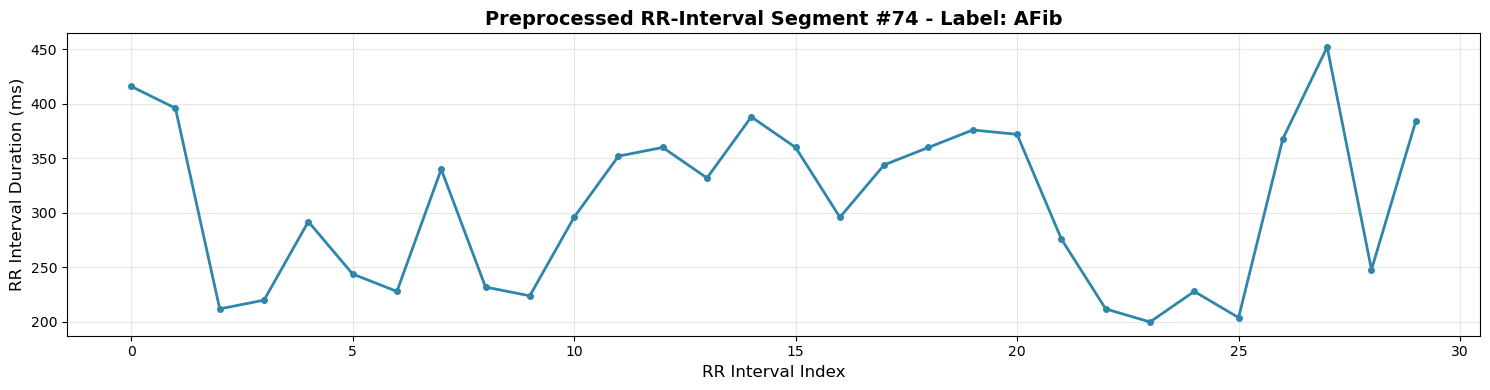


════════════════════════════════════════════════════════════════════════════════



In [11]:
# ───────────────────────────────────────────────────────────────────────
# Visualize a sample
# ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(15, 4))
    
# Find first AFib sample
afib_indices = np.where(y == 1)[0]
if len(afib_indices) > 0:
    idx = afib_indices[0]
    label_name = 'AFib'
else:
    idx = 0
    label_name = 'Normal'

sample = X[idx]

plt.plot(sample, marker='o', linestyle='-', linewidth=2, markersize=4, color='#2E86AB')
plt.title(f'Preprocessed RR-Interval Segment #{idx} - Label: {label_name}', 
            fontsize=14, fontweight='bold')
plt.xlabel('RR Interval Index', fontsize=12)
plt.ylabel('RR Interval Duration (ms)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'═'*80}\n")

Part 3: Model Training

In [2]:
import sys
sys.path.append('/storage/scratch2/e20-fyp-atfib-det/modelFolder')

from universal_trainer import train_afib_model
from afib_reslstm import AFibResLSTM, MODEL_CONFIG

results = train_afib_model(
    model_name='afib_reslstm',
    model_class=AFibResLSTM,
    model_config=MODEL_CONFIG,
    processed_data_dir='/storage/scratch2/e20-fyp-atfib-det/data/processed',
    results_save_dir='/storage/scratch2/e20-fyp-atfib-det/results',
    epochs=100,
    batch_size=32,
    learning_rate=0.0001,
    early_stopping_patience=5,
    use_class_weights=True
)

CONFIGURATION
────────────────────────────────────────────────────────────────────────────────
   Model:          afib_reslstm
   Device:         cuda
   Epochs:         100
   Learning Rate:  0.0001
   Batch Size:     32
   Random Seed:    42
   Early Stop:     5 epochs patience

📂 PATHS
────────────────────────────────────────────────────────────────────────────────
   Data:    /storage/scratch2/e20-fyp-atfib-det/data/processed/afib_reslstm
   Results: /storage/scratch2/e20-fyp-atfib-det/results/afib_reslstm
Loading data from: afib_reslstm/
X shape: (175526, 7500)
y shape: (175526,)

SHUFFLING DATA
Data shuffled successfully
Verification - First 20 labels: [1 1 1 0 0 1 1 1 0 1 0 1 1 0 0 0 1 0 1 0]
Expected: Mix of 0s and 1s (not sorted)

CLASS DISTRIBUTION
   ────────────────────────────────────────
      Normal   (0): 106,381 samples ( 60.6%) ██████████████████████████████
      AFib     (1): 69,145 samples ( 39.4%) ███████████████████
Stratified split successful
      DataLoaders c

Epoch 1/100 [Train]:   0%|          | 0/3840 [00:00<?, ?it/s]

Epoch 1/100 [Val]  :   0%|          | 0/823 [00:00<?, ?it/s]


   ──────────────────────────────────────────────────────────────────────
   Epoch 1/100 Results:
   ──────────────────────────────────────────────────────────────────────
   Train │ Loss:  0.0255 │ Acc: 0.9486
   Val   │ Loss:  0.6954 │ Acc: 0.5987 │ F1: 0.5438 │ AUROC: 0.6103
   New best model! (AUROC: 0.6103)


Epoch 2/100 [Train]:   0%|          | 0/3840 [00:00<?, ?it/s]

...

Epoch 13/100 [Train]:   0%|          | 0/3840 [00:00<?, ?it/s]

Epoch 13/100 [Val]  :   0%|          | 0/823 [00:00<?, ?it/s]


   ──────────────────────────────────────────────────────────────────────
   Epoch 13/100 Results:
   ──────────────────────────────────────────────────────────────────────
   Train │ Loss:  0.0051 │ Acc: 0.9904
   Val   │ Loss:  0.4096 │ Acc: 0.5556 │ F1: 0.5141 │ AUROC: 0.5096
 No improvement (5/5)

     Early stopping triggered at epoch 13


Testing:   0%|          | 0/823 [00:00<?, ?it/s]


 TEST SET PERFORMANCE
   ══════════════════════════════════════════════════════════════════════
   Accuracy:    0.5585  (55.85%)
   F1-Score:    0.5191
   AUROC:       0.5120
   Sensitivity: 0.6048  (Recall for AFib)
   Specificity: 0.5284  (Recall for Normal)
   PPV:         0.4546  (Precision for AFib)
   NPV:         0.6729  (Precision for Normal)

  CONFUSION MATRIX
   ────────────────────────────────────────
              Predicted
            Normal    AFib
   Actual N    8431    7526
          A    4099    6273

════════════════════════════════════════════════════════════════════════════════
STEP 7: SAVING RESULTS
════════════════════════════════════════════════════════════════════════════════

   Model checkpoint saved: best_model.pth
  Results saved: results.json
   ✅ Training plots saved: training_history.png
   Classification report saved: classification_report.txt

   All results saved to: /storage/scratch2/e20-fyp-atfib-det/results/afib_reslstm

══════════════════════════

In [3]:
import torch
from pathlib import Path

# Load the saved "best" model
checkpoint = torch.load('/storage/scratch2/e20-fyp-atfib-det/results/afib_reslstm/best_model.pth')

print("📊 SAVED MODEL INFO:")
print(f"Best Val AUROC: {checkpoint['training_info']['best_val_auroc']:.4f}")
print(f"Best Epoch: {checkpoint['training_info'].get('best_epoch', 'Unknown')}")
print(f"Total Epochs: {checkpoint['training_info']['total_epochs']}")

# The test metrics in checkpoint are WRONG - they're from after overfitting
print(f"\n⚠️ Test AUROC in checkpoint: {checkpoint['test_metrics']['auroc']:.4f}")
print("(This is low because test was evaluated AFTER overfitting)")

📊 SAVED MODEL INFO:
Best Val AUROC: 0.9943
Best Epoch: 8
Total Epochs: 24

⚠️ Test AUROC in checkpoint: 0.5981
(This is low because test was evaluated AFTER overfitting)


In [4]:
import numpy as np

# Load your preprocessed data
X = np.load('/storage/scratch2/e20-fyp-atfib-det/data/processed/afib_reslstm/X_processed.npy')
y = np.load('/storage/scratch2/e20-fyp-atfib-det/data/processed/afib_reslstm/y_processed.npy')

print(f"Total samples: {len(y)}")
print(f"AFib: {np.sum(y==1)} ({np.sum(y==1)/len(y)*100:.1f}%)")
print(f"Normal: {np.sum(y==0)} ({np.sum(y==0)/len(y)*100:.1f}%)")

# Check if there's data leakage or sorting issues
print(f"\nFirst 100 labels: {y[:100]}")
print(f"Last 100 labels: {y[-100:]}")

# If all 0s or all 1s are clustered, that's BAD!

Total samples: 175526
AFib: 69145 (39.4%)
Normal: 106381 (60.6%)

First 100 labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
Last 100 labels: [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 1 1 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [3]:
import sys
sys.path.append('/storage/scratch2/e20-fyp-atfib-det/modelFolder')

from universal_trainer import train_afib_model
from cnn_bilstm import CNNBiLSTM, MODEL_CONFIG

# Train!
results = train_afib_model(
    model_name='cnn_bilstm',
    model_class=CNNBiLSTM,
    model_config=MODEL_CONFIG,
    processed_data_dir='/storage/scratch2/e20-fyp-atfib-det/data/processed',
    results_save_dir='/storage/scratch2/e20-fyp-atfib-det/results',
    epochs=100,
    batch_size=32,
    learning_rate=0.001
)
print("\n TRAINING COMPLETE!")
print(f"Final AUROC: {results['test_metrics']['auroc']:.4f}")

CONFIGURATION
────────────────────────────────────────────────────────────────────────────────
   Model:          cnn_bilstm
   Device:         cuda
   Epochs:         100
   Learning Rate:  0.001
   Batch Size:     32
   Random Seed:    42
   Early Stop:     15 epochs patience

📂 PATHS
────────────────────────────────────────────────────────────────────────────────
   Data:    /storage/scratch2/e20-fyp-atfib-det/data/processed/cnn_bilstm
   Results: /storage/scratch2/e20-fyp-atfib-det/results/cnn_bilstm
Loading data from: cnn_bilstm/
X shape: (174161, 30)
y shape: (174161,)

CLASS DISTRIBUTION
   ────────────────────────────────────────
      Normal   (0): 109,876 samples ( 63.1%) ███████████████████████████████
      AFib     (1): 64,285 samples ( 36.9%) ██████████████████
Stratified split successful
      DataLoaders created:
      Train: 3810 batches × 32 samples
      Val:    817 batches × 32 samples
      Test:   817 batches × 32 samples
      Using weighted CrossEntropyLoss
    

Epoch 1/100 [Train]:   0%|          | 0/3810 [00:00<?, ?it/s]

Epoch 1/100 [Val]  :   0%|          | 0/817 [00:00<?, ?it/s]


   ──────────────────────────────────────────────────────────────────────
   Epoch 1/100 Results:
   ──────────────────────────────────────────────────────────────────────
   Train │ Loss:  0.4741 │ Acc: 0.7538
   Val   │ Loss:  0.4754 │ Acc: 0.7978 │ F1: 0.7029 │ AUROC: 0.8875
   New best model! (AUROC: 0.8875)


Epoch 2/100 [Train]:   0%|          | 0/3810 [00:00<?, ?it/s]

...

Epoch 24/100 [Train]:   0%|          | 0/3810 [00:00<?, ?it/s]

Epoch 24/100 [Val]  :   0%|          | 0/817 [00:00<?, ?it/s]


   ──────────────────────────────────────────────────────────────────────
   Epoch 24/100 Results:
   ──────────────────────────────────────────────────────────────────────
   Train │ Loss:  0.0971 │ Acc: 0.9632
   Val   │ Loss:  0.6868 │ Acc: 0.8287 │ F1: 0.7759 │ AUROC: 0.9061
 No improvement (15/15)

     Early stopping triggered at epoch 24


Testing:   0%|          | 0/817 [00:00<?, ?it/s]


 TEST SET PERFORMANCE
   ══════════════════════════════════════════════════════════════════════
   Accuracy:    0.8312  (83.12%)
   F1-Score:    0.7798
   AUROC:       0.9080
   Sensitivity: 0.8101  (Recall for AFib)
   Specificity: 0.8435  (Recall for Normal)
   PPV:         0.7517  (Precision for AFib)
   NPV:         0.8836  (Precision for Normal)

  CONFUSION MATRIX
   ────────────────────────────────────────
              Predicted
            Normal    AFib
   Actual N   13902    2580
          A    1831    7812

════════════════════════════════════════════════════════════════════════════════
STEP 7: SAVING RESULTS
════════════════════════════════════════════════════════════════════════════════

   Model checkpoint saved: best_model.pth
  Results saved: results.json
   ✅ Training plots saved: training_history.png
   Classification report saved: classification_report.txt

   All results saved to: /storage/scratch2/e20-fyp-atfib-det/results/cnn_bilstm

════════════════════════════

In [1]:
import sys
sys.path.append('/storage/scratch2/e20-fyp-atfib-det/modelFolder')

from universal_trainer import train_afib_model
from cnn_lstm_focal import CNNLSTMFocal, MODEL_CONFIG

# Train!
results = train_afib_model(
    model_name='cnn_lstm_focal',
    model_class=CNNLSTMFocal,
    model_config=MODEL_CONFIG,
    processed_data_dir='/storage/scratch2/e20-fyp-atfib-det/data/processed',
    results_save_dir='/storage/scratch2/e20-fyp-atfib-det/results',
    epochs=100,
    batch_size=32,
    learning_rate=0.001
)
print("\n TRAINING COMPLETE!")
print(f"Final AUROC: {results['test_metrics']['auroc']:.4f}")

CONFIGURATION
────────────────────────────────────────────────────────────────────────────────
   Model:          cnn_lstm_focal
   Device:         cuda
   Epochs:         100
   Learning Rate:  0.001
   Batch Size:     32
   Random Seed:    42
   Early Stop:     15 epochs patience

📂 PATHS
────────────────────────────────────────────────────────────────────────────────
   Data:    /storage/scratch2/e20-fyp-atfib-det/data/processed/cnn_lstm_focal
   Results: /storage/scratch2/e20-fyp-atfib-det/results/cnn_lstm_focal
Loading data from: cnn_lstm_focal/
X shape: (702031, 187)
y shape: (702031,)

SHUFFLING DATA
Data shuffled successfully
Verification - First 20 labels: ['N' 'N' 'N' 'N' 'N' 'AFIB' 'N' 'AFIB' 'N' 'N' 'AFIB' 'N' 'N' 'N' 'N' 'N'
 'N' 'N' 'N' 'N']
Expected: Mix of 0s and 1s (not sorted)

CLASS DISTRIBUTION
   ────────────────────────────────────────
      AFib     (AFIB): 112,037 samples ( 16.0%) ███████
      AFib     (N): 589,994 samples ( 84.0%) █████████████████████████████

Epoch 1/100 [Train]:   0%|          | 0/15357 [00:00<?, ?it/s]

Epoch 1/100 [Val]  :   0%|          | 0/3291 [00:00<?, ?it/s]


   ──────────────────────────────────────────────────────────────────────
   Epoch 1/100 Results:
   ──────────────────────────────────────────────────────────────────────
   Train │ Loss:  0.0193 │ Acc: 0.9456
   Val   │ Loss:  0.1820 │ Acc: 0.8404 │ F1: 0.0002 │ AUROC: 0.3846
   New best model! (AUROC: 0.3846)


Epoch 2/100 [Train]:   0%|          | 0/15357 [00:00<?, ?it/s]

...

Epoch 3/100 [Train]:   0%|          | 0/15357 [00:00<?, ?it/s]

Epoch 3/100 [Val]  :   0%|          | 0/3291 [00:00<?, ?it/s]


   ──────────────────────────────────────────────────────────────────────
   Epoch 3/100 Results:
   ──────────────────────────────────────────────────────────────────────
   Train │ Loss:  0.0156 │ Acc: 0.9573
   Val   │ Loss:  0.2023 │ Acc: 0.8403 │ F1: 0.0066 │ AUROC: 0.4125
   New best model! (AUROC: 0.4125)


Epoch 4/100 [Train]:   0%|          | 0/15357 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [1]:
import sys
sys.path.append('/storage/scratch2/e20-fyp-atfib-det/modelFolder')

from universal_trainer import train_afib_model
from lightweight_resnet import LightweightResNet, MODEL_CONFIG

# Train!
results = train_afib_model(
    model_name='lightweight_resnet',
    model_class=LightweightResNet,
    model_config=MODEL_CONFIG,
    processed_data_dir='/storage/scratch2/e20-fyp-atfib-det/data/processed',
    results_save_dir='/storage/scratch2/e20-fyp-atfib-det/results',
    epochs=100,
    batch_size=32,
    learning_rate=0.0001
)
print("\n TRAINING COMPLETE!")
print(f"Final AUROC: {results['test_metrics']['auroc']:.4f}")

CONFIGURATION
────────────────────────────────────────────────────────────────────────────────
   Model:          lightweight_resnet
   Device:         cuda
   Epochs:         100
   Learning Rate:  0.001
   Batch Size:     32
   Random Seed:    42
   Early Stop:     15 epochs patience

📂 PATHS
────────────────────────────────────────────────────────────────────────────────
   Data:    /storage/scratch2/e20-fyp-atfib-det/data/processed/lightweight_resnet
   Results: /storage/scratch2/e20-fyp-atfib-det/results/lightweight_resnet
Loading data from: lightweight_resnet/
X shape: (32145, 6000)
y shape: (32145,)

SHUFFLING DATA
Data shuffled successfully
Verification - First 20 labels: [0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0]
Expected: Mix of 0s and 1s (not sorted)

CLASS DISTRIBUTION
   ────────────────────────────────────────
      Normal   (0): 20,407 samples ( 63.5%) ███████████████████████████████
      AFib     (1): 11,738 samples ( 36.5%) ██████████████████
Stratified split successfu

Epoch 1/100 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 1/100 [Val]  :   0%|          | 0/151 [00:00<?, ?it/s]


   ──────────────────────────────────────────────────────────────────────
   Epoch 1/100 Results:
   ──────────────────────────────────────────────────────────────────────
   Train │ Loss:  0.6040 │ Acc: 0.6459
   Val   │ Loss:  2.6185 │ Acc: 0.6522 │ F1: 0.0911 │ AUROC: 0.4492
   New best model! (AUROC: 0.4492)


Epoch 2/100 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

...

Epoch 41/100 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 41/100 [Val]  :   0%|          | 0/151 [00:00<?, ?it/s]


   ──────────────────────────────────────────────────────────────────────
   Epoch 41/100 Results:
   ──────────────────────────────────────────────────────────────────────
   Train │ Loss:  0.0053 │ Acc: 0.9983
   Val   │ Loss:  0.2517 │ Acc: 0.9490 │ F1: 0.9264 │ AUROC: 0.9941
 No improvement (15/15)

     Early stopping triggered at epoch 41


Testing:   0%|          | 0/151 [00:00<?, ?it/s]


 TEST SET PERFORMANCE
   ══════════════════════════════════════════════════════════════════════
   Accuracy:    0.9554  (95.54%)
   F1-Score:    0.9358
   AUROC:       0.9950
   Sensitivity: 0.8904  (Recall for AFib)
   Specificity: 0.9928  (Recall for Normal)
   PPV:         0.9862  (Precision for AFib)
   NPV:         0.9403  (Precision for Normal)

  CONFUSION MATRIX
   ────────────────────────────────────────
              Predicted
            Normal    AFib
   Actual N    3039      22
          A     193    1568

════════════════════════════════════════════════════════════════════════════════
STEP 7: SAVING RESULTS
════════════════════════════════════════════════════════════════════════════════

   Model checkpoint saved: best_model.pth
  Results saved: results.json
   ✅ Training plots saved: training_history.png
   Classification report saved: classification_report.txt

   All results saved to: /storage/scratch2/e20-fyp-atfib-det/results/lightweight_resnet

════════════════════

In [1]:
import sys
sys.path.append('/storage/scratch2/e20-fyp-atfib-det/modelFolder')

from universal_trainer import train_afib_model
from resnet_bilstm_attention import ResNetBiLSTMAttention, MODEL_CONFIG

# Train!
results = train_afib_model(
    model_name='resnet_bilstm_attention',
    model_class=ResNetBiLSTMAttention,
    model_config=MODEL_CONFIG,
    processed_data_dir='/storage/scratch2/e20-fyp-atfib-det/data/processed',
    results_save_dir='/storage/scratch2/e20-fyp-atfib-det/results',
    epochs=100,
    batch_size=32,
    learning_rate=0.001
)
print("\n TRAINING COMPLETE!")
print(f"Final AUROC: {results['test_metrics']['auroc']:.4f}")

CONFIGURATION
────────────────────────────────────────────────────────────────────────────────
   Model:          resnet_bilstm_attention
   Device:         cuda
   Epochs:         100
   Learning Rate:  0.001
   Batch Size:     32
   Random Seed:    42
   Early Stop:     15 epochs patience

📂 PATHS
────────────────────────────────────────────────────────────────────────────────
   Data:    /storage/scratch2/e20-fyp-atfib-det/data/processed/resnet_bilstm_attention
   Results: /storage/scratch2/e20-fyp-atfib-det/results/resnet_bilstm_attention
Loading data from: resnet_bilstm_attention/
X shape: (175526, 7500)
y shape: (175526,)

SHUFFLING DATA
Data shuffled successfully
Verification - First 20 labels: [1 1 1 0 0 1 1 1 0 1 0 1 1 0 0 0 1 0 1 0]
Expected: Mix of 0s and 1s (not sorted)

CLASS DISTRIBUTION
   ────────────────────────────────────────
      Normal   (0): 106,381 samples ( 60.6%) ██████████████████████████████
      AFib     (1): 69,145 samples ( 39.4%) ███████████████████
Str

Epoch 1/100 [Train]:   0%|          | 0/3840 [00:00<?, ?it/s]

Epoch 1/100 [Val]  :   0%|          | 0/823 [00:00<?, ?it/s]


   ──────────────────────────────────────────────────────────────────────
   Epoch 1/100 Results:
   ──────────────────────────────────────────────────────────────────────
   Train │ Loss:  0.1023 │ Acc: 0.9585
   Val   │ Loss:  2.9793 │ Acc: 0.3795 │ F1: 0.5267 │ AUROC: 0.6467
   New best model! (AUROC: 0.6467)


Epoch 2/100 [Train]:   0%|          | 0/3840 [00:00<?, ?it/s]

...

Epoch 16/100 [Train]:   0%|          | 0/3840 [00:00<?, ?it/s]

Epoch 16/100 [Val]  :   0%|          | 0/823 [00:00<?, ?it/s]


   ──────────────────────────────────────────────────────────────────────
   Epoch 16/100 Results:
   ──────────────────────────────────────────────────────────────────────
   Train │ Loss:  0.0184 │ Acc: 0.9938
   Val   │ Loss:  1.3260 │ Acc: 0.6082 │ F1: 0.0155 │ AUROC: 0.5554
 No improvement (15/15)

     Early stopping triggered at epoch 16


Testing:   0%|          | 0/823 [00:00<?, ?it/s]


 TEST SET PERFORMANCE
   ══════════════════════════════════════════════════════════════════════
   Accuracy:    0.6088  (60.88%)
   F1-Score:    0.0183
   AUROC:       0.5441
   Sensitivity: 0.0093  (Recall for AFib)
   Specificity: 0.9986  (Recall for Normal)
   PPV:         0.8067  (Precision for AFib)
   NPV:         0.6079  (Precision for Normal)

  CONFUSION MATRIX
   ────────────────────────────────────────
              Predicted
            Normal    AFib
   Actual N   15934      23
          A   10276      96

════════════════════════════════════════════════════════════════════════════════
STEP 7: SAVING RESULTS
════════════════════════════════════════════════════════════════════════════════

   Model checkpoint saved: best_model.pth
  Results saved: results.json
   ✅ Training plots saved: training_history.png
   Classification report saved: classification_report.txt

   All results saved to: /storage/scratch2/e20-fyp-atfib-det/results/resnet_bilstm_attention

═══════════════

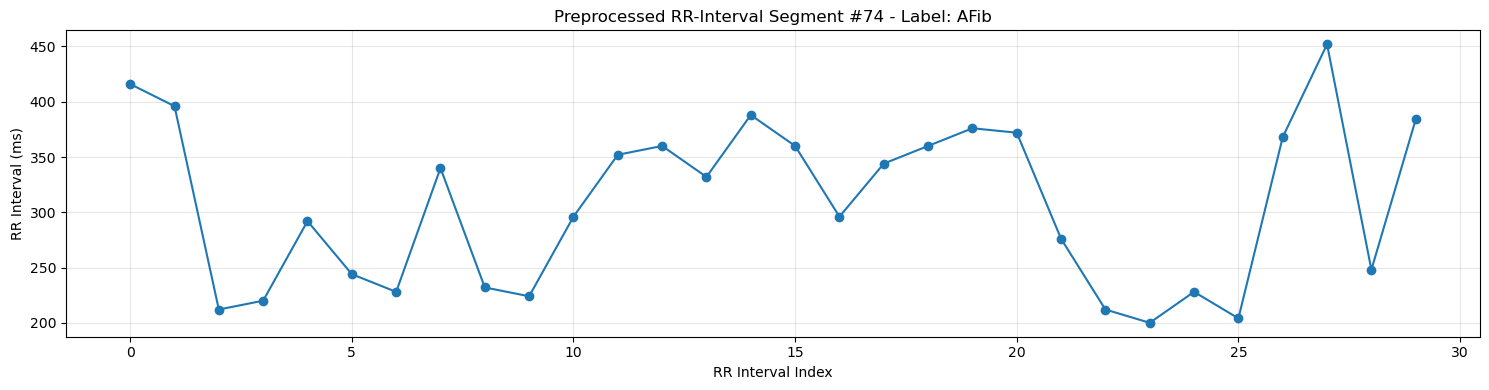

In [6]:
# Visualize a preprocessed segment (if data was loaded)
if len(X) > 0:
    plt.figure(figsize=(15, 4))
    segment_idx = 0 
    
    # Find first AFib sample to plot (if any)
    afib_indices = np.where(y == 1)[0]
    if len(afib_indices) > 0:
        segment_idx = afib_indices[0]
        
    segment = X[segment_idx]
    label = 'AFib' if y[segment_idx] == 1 else 'Normal'

    # The data for cnn_bilstm is RR intervals, not a raw signal
    plt.plot(segment, marker='o', linestyle='-')
    plt.title(f'Preprocessed RR-Interval Segment #{segment_idx} - Label: {label}')
    plt.xlabel('RR Interval Index')
    plt.ylabel('RR Interval (ms)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data loaded, skipping visualization.")

List Available Models

In [7]:
# List Available Models

# %%
from universal_trainer import ModelRegistry

# --- START FIX: Pass the correct absolute path ---
registry = ModelRegistry(models_dir=str(MODEL_FOLDER_PATH))
# --- END FIX ---

print("\n📋 Available Models:")
registry.list_models()

Discovering models in: /storage/scratch2/e20-fyp-atfib-det/modelFolder
✅ Registered: cnn_lstm_focal
✅ Registered: cnn_bilstm
✅ Registered: afib_reslstm
✅ Registered: lightweight_resnet
✅ Registered: resnet_bilstm_attention

📋 Available Models:

📋 Available Models:

🔹 cnn_lstm_focal
   Name: CNN-LSTM-Focal
   Description: Highest specificity model with focal loss
   Reference: Petmezas et al. 2021, Biomedical Signal Processing

🔹 cnn_bilstm
   Name: CNN-BiLSTM
   Description: Efficient real-time model for AFib detection
   Reference: Andersen et al. 2019, Expert Systems with Applications

🔹 afib_reslstm
   Name: AFib-ResLSTM (Novel)
   Description: Multi-scale + ResNet-34 + BiLSTM + Self-Attention + Hybrid Fusion
   Reference: Your Research 2025

🔹 lightweight_resnet
   Name: Lightweight-ResNet
   Description: 99% sparse model for edge deployment
   Reference: Lueken et al. 2025, Large-scale Screening Study

🔹 resnet_bilstm_attention
   Name: ResNet-BiLSTM-Attention
   Description: Good

In [10]:
from universal_trainer import train_model
# Train CNN-BiLSTM model
print("\n" + "="*70)
print("TRAINING CNN-BiLSTM MODEL")
print("="*70 + "\n")

# --- START FIX: Corrected paths ---
results = train_model(
    model_name='cnn_bilstm',
    models_dir=str('/storage/scratch2/e20-fyp-atfib-det/modelFolder'),
    
    # FIX 1: Path changed to the ROOT processed directory
    data_path=str('/storage/scratch2/e20-fyp-atfib-det/data/processed/'), 
    
    # FIX 2: save_dir should be the ROOT results directory
    save_dir=str('/storage/scratch2/e20-fyp-atfib-det/results_new/'), 
    
    epochs=20,  # Reduced for demo
    lr=0.001,
    batch_size=32,
    device='auto',
    early_stopping_patience=10,
    random_seed=42
)
# --- END FIX ---

print(f"\n✅ Training Complete!")
print(f"   Test AUROC: {results['test_metrics']['auroc']:.4f}")
print(f"   Test F1: {results['test_metrics']['f1_score']:.4f}")
print(f"   Sensitivity: {results['test_metrics']['sensitivity']:.4f}")
print(f"   Specificity: {results['test_metrics']['specificity']:.4f}")


TRAINING CNN-BiLSTM MODEL


🚀 UNIVERSAL MODEL TRAINER

⚙️  Configuration:
   Model: cnn_bilstm
   Device: cuda
   Epochs: 20
   Learning Rate: 0.001
   Batch Size: 32

📦 Loading model...
Discovering models in: /storage/scratch2/e20-fyp-atfib-det/modelFolder
❌ Failed to load cnn_lstm_focal.py: parent 'modelFolder' not in sys.modules
❌ Failed to load cnn_bilstm.py: parent 'modelFolder' not in sys.modules
❌ Failed to load afib_reslstm.py: parent 'modelFolder' not in sys.modules
❌ Failed to load lightweight_resnet.py: parent 'modelFolder' not in sys.modules
❌ Failed to load resnet_bilstm_attention.py: parent 'modelFolder' not in sys.modules
⚠️ Registry is empty. Retrying discovery...
Discovering models in: /storage/scratch2/e20-fyp-atfib-det/modelFolder
❌ Failed to load cnn_lstm_focal.py: parent 'modelFolder' not in sys.modules
❌ Failed to load cnn_bilstm.py: parent 'modelFolder' not in sys.modules
❌ Failed to load afib_reslstm.py: parent 'modelFolder' not in sys.modules
❌ Failed to load 

ValueError: Model 'cnn_bilstm' not found. Available: []

KeyboardInterrupt: 

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
import json
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# ============================================================================
# STEP 1: DEFINE YOUR MODEL (Pasted from your file)
# ============================================================================

class CNNBiLSTM(nn.Module):
    """
    Efficient CNN-BiLSTM for real-time AFib detection
    Reference: Andersen et al. 2019
    """
    
    def __init__(self, config):
        super(CNNBiLSTM, self).__init__()
        
        # CNN blocks
        self.conv1 = nn.Conv1d(1, 60, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(60)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(60, 80, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(80)
        self.pool2 = nn.MaxPool1d(2)
        
        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=80,
            hidden_size=100,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(200, 2)
    
    def forward(self, x):
        # CNN
        # Note: Your model code doesn't show an input dimension check, 
        # but the cnn_bilstm data is (Batch, 30). Conv1d expects (Batch, Channels, Length).
        # We must add the channel dimension if it's missing.
        if x.ndim == 2:
            x = x.unsqueeze(1) # (Batch, 30) -> (Batch, 1, 30)
        
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        # BiLSTM
        x = x.transpose(1, 2)
        lstm_out, _ = self.lstm(x)
        lstm_out = self.dropout(lstm_out)
        pooled = torch.mean(lstm_out, dim=1)
        
        # Output
        logits = self.fc(pooled)
        return logits

# This is what the universal trainer was looking for:
MODEL_CLASS = CNNBiLSTM
MODEL_CONFIG = {
    'name': 'CNN-BiLSTM',
    'description': 'Efficient real-time model for AFib detection',
    'reference': 'Andersen et al. 2019, Expert Systems with Applications',
    'performance': 'Se=98.98%, Sp=96.95%',
    'num_classes': 2,
    'optimizer': {
        'type': 'SGD',
        'momentum': 0.99,
        'weight_decay': 0.000017
    }
}

print("✅ Step 1: Model class defined.")

# ============================================================================
# STEP 2: DEFINE THE DATASET CLASS (Copied from universal_trainer.py)
# ============================================================================

class ECGDataset(Dataset):
    """Universal ECG dataset that works with any model"""
    
    def __init__(self, X, y, transform=None):
        self.X = torch.FloatTensor(X)
        
        # cnn_bilstm (RR-intervals) is (Batch, Length), no channel dim needed yet.
        # Other models are (Batch, Channels, Length)
        if self.X.ndim == 3 and self.X.shape[1] == 1:
             # Squeeze (Batch, 1, Length) -> (Batch, Length) if it's RR data
             # Let's check the model type. For cnn_bilstm, data is 2D.
             if MODEL_CONFIG['name'] == 'CNN-BiLSTM':
                 self.X = self.X.squeeze(1)
        
        # Add channel dimension if it's 2D (for CNN models)
        # BUT cnn_bilstm model's forward pass handles this.
        # Let's keep data as (Batch, Length) or (Batch, Channels, Length)
        
        # Convert labels to integers
        if len(y) > 0 and not np.issubdtype(y.dtype, np.integer):
            label_map = {'N': 0, 'A': 1, 'normal': 0, 'afib': 1}
            y_int = []
            for label in y:
                if isinstance(label, str):
                    y_int.append(label_map.get(str(label).lower(), 0))
                else:
                    y_int.append(int(label))
            y = np.array(y_int)
        
        self.y = torch.LongTensor(y)
        self.transform = transform
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        ecg = self.X[idx]
        label = self.y[idx]
        
        if self.transform:
            ecg = self.transform(ecg)
        
        return ecg, label

print("✅ Step 2: ECGDataset class defined.")

# ============================================================================
# STEP 3: DEFINE PARAMETERS (Your manual settings)
# ============================================================================

# --- YOUR PATHS ---
DATA_PATH_STR = '/storage/scratch2/e20-fyp-atfib-det/data/processed/cnn_bilstm'
SAVE_DIR_STR = '/storage/scratch2/e20-fyp-atfib-det/results_new/cnn_bilstm'

# --- TRAINING SETTINGS ---
EPOCHS = 20
LEARNING_RATE = 0.001
BATCH_SIZE = 32
DEVICE_STR = 'auto'
EARLY_STOPPING_PATIENCE = 10
RANDOM_SEED = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15
USE_CLASS_WEIGHTS = True

print("✅ Step 3: Parameters set.")

# ============================================================================
# STEP 4: TRAINING SCRIPT (Logic from universal_trainer.py)
# ============================================================================

print(f"\n{'='*70}")
print(f"🚀 MANUAL MODEL TRAINER (Bypassing universal_trainer)")
print(f"{'='*70}")

# --- 4a. Setup Device and Seed ---
if DEVICE_STR == 'auto':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
else:
    device = torch.device(DEVICE_STR)

print(f"\n⚙️  Configuration:")
print(f"   Model: {MODEL_CONFIG['name']}")
print(f"   Device: {device}")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Batch Size: {BATCH_SIZE}")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# --- 4b. Load Model (Manually) ---
print(f"\n📦 Loading model...")
model_config = MODEL_CONFIG.copy()
model_config.update({
    'learning_rate': LEARNING_RATE,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS
})
model = MODEL_CLASS(model_config).to(device)
print(f"   ✅ Model loaded: {model_config.get('name', 'N/A')}")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Trainable Parameters: {total_params:,}")

# --- 4c. Load Data ---
print(f"\n📊 Loading data from: {DATA_PATH_STR}")
data_path = Path(DATA_PATH_STR)
X_path = data_path / 'X_processed.npy'
y_path = data_path / 'y_processed.npy'

if not X_path.exists() or not y_path.exists():
    raise FileNotFoundError(f"Data not found at {data_path}. Looked for X_processed.npy and y_processed.npy")

X = np.load(X_path)
y = np.load(y_path)
print(f"   Data shape: {X.shape}, Labels shape: {y.shape}")
unique, counts = np.unique(y, return_counts=True)
print(f"   Class Distribution: {dict(zip(unique, counts))}")

# --- 4d. Split Data ---
print(f"\n📂 Splitting data...")
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)
val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_size_adjusted,
    random_state=RANDOM_SEED,
    stratify=y_trainval
)
print(f"   Train: {X_train.shape[0]} samples")
print(f"   Val:   {X_val.shape[0]} samples")
print(f"   Test:  {X_test.shape[0]} samples")

# --- 4e. Create DataLoaders ---
train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True if device.type == 'cuda' else False
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True if device.type == 'cuda' else False
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True if device.type == 'cuda' else False
)

# --- 4f. Training Setup ---
print(f"\n🔧 Setting up training...")
if USE_CLASS_WEIGHTS:
    class_counts = np.bincount(y_train)
    if len(class_counts) < 2:
        print("   ⚠️  Only one class in training data! Disabling class weights.")
        criterion = nn.CrossEntropyLoss()
    else:
        weights = len(y_train) / (len(class_counts) * class_counts)
        class_weights = torch.FloatTensor(weights).to(device)
        print(f"   Class weights: {class_weights.cpu().numpy()}")
        criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, verbose=True
)

history = {
    'train_loss': [], 'train_acc': [], 'val_loss': [], 
    'val_acc': [], 'val_f1': [], 'val_auroc': [], 'learning_rates': []
}
best_val_auroc = 0.0
best_model_state = None
patience_counter = 0

# --- 4g. Training Loop ---
print(f"\n{'='*70}")
print(f"🎯 STARTING TRAINING")
print(f"{'='*70}\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_preds, train_labels = 0.0, [], []
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} [Train]')
    for ecg, labels in pbar:
        ecg, labels = ecg.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(ecg)
        logits = outputs[0] if isinstance(outputs, tuple) else outputs
        
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_train_loss = train_loss / len(train_loader)
    epoch_train_acc = accuracy_score(train_labels, train_preds)

    model.eval()
    val_loss, val_preds, val_labels, val_probs = 0.0, [], [], []
    with torch.no_grad():
        for ecg, labels in tqdm(val_loader, desc=f'Epoch {epoch}/{EPOCHS} [Val]  ', leave=False):
            ecg, labels = ecg.to(device), labels.to(device)
            outputs = model(ecg)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            
            loss = criterion(logits, labels)
            val_loss += loss.item()
            
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
            if probs.shape[1] > 1:
                val_probs.extend(probs[:, 1].cpu().numpy())
            else:
                val_probs.extend(torch.zeros_like(preds).cpu().numpy())

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = accuracy_score(val_labels, val_preds)
    epoch_val_f1 = f1_score(val_labels, val_preds, zero_division=0)
    
    try:
        epoch_val_auroc = roc_auc_score(val_labels, val_probs)
    except ValueError:
        epoch_val_auroc = 0.5
        print("   ⚠️  AUROC warning: Only one class present in validation batch.")

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    history['val_f1'].append(epoch_val_f1)
    history['val_auroc'].append(epoch_val_auroc)
    history['learning_rates'].append(optimizer.param_groups[0]['lr'])

    print(f"\nEpoch {epoch}/{EPOCHS}:")
    print(f"   Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"   Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")
    print(f"   Val F1:     {epoch_val_f1:.4f} | Val AUROC: {epoch_val_auroc:.4f}")

    scheduler.step(epoch_val_auroc)

    if epoch_val_auroc > best_val_auroc:
        best_val_auroc = epoch_val_auroc
        best_model_state = model.state_dict()
        patience_counter = 0
        print(f"   ✅ New best model! (AUROC: {best_val_auroc:.4f})")
    else:
        patience_counter += 1
        print(f"   No improvement ({patience_counter}/{EARLY_STOPPING_PATIENCE})")

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n⏹️  Early stopping triggered after {epoch} epochs")
        break

# --- 4h. Test Evaluation ---
print(f"\n{'='*70}")
print(f"📊 FINAL EVALUATION ON TEST SET")
print(f"{'='*70}\n")

if best_model_state is None:
    print("   ⚠️  No best model saved. Using last model state.")
    best_model_state = model.state_dict()

model.load_state_dict(best_model_state)
model.eval()
test_preds, test_labels, test_probs = [], [], []

with torch.no_grad():
    for ecg, labels in tqdm(test_loader, desc='Testing'):
        ecg, labels = ecg.to(device), labels.to(device)
        outputs = model(ecg)
        logits = outputs[0] if isinstance(outputs, tuple) else outputs
        
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        if probs.shape[1] > 1:
            test_probs.extend(probs[:, 1].cpu().numpy())
        else:
            test_probs.extend(torch.zeros_like(preds).cpu().numpy())

test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, zero_division=0)
try:
    test_auroc = roc_auc_score(test_labels, test_probs)
except ValueError:
    test_auroc = 0.5
    print("   ⚠️  AUROC warning: Only one class present in test set.")

cm = confusion_matrix(test_labels, test_preds)
if len(cm.ravel()) == 4:
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
else:
    # Handle edge case where model only predicts one class
    tn, fp, fn, tp = 0, 0, 0, 0
    sensitivity, specificity = 0.0, 0.0
    print(f"   ⚠️  Confusion matrix error. Predictions may be skewed to one class.")
    print(cm)


print(f"Test Results:")
print(f"   Accuracy:    {test_acc:.4f}")
print(f"   F1-Score:    {test_f1:.4f}")
print(f"   AUROC:       {test_auroc:.4f}")
print(f"   Sensitivity: {sensitivity:.4f}")
print(f"   Specificity: {specificity:.4f}")
print(f"\nConfusion Matrix:")
print(f"   TN: {tn:5d}  |  FP: {fp:5d}")
print(f"   FN: {fn:5d}  |  TP: {tp:5d}")

# --- 4i. Save Results ---
save_dir = Path(SAVE_DIR_STR)
save_dir.mkdir(parents=True, exist_ok=True)
print(f"\n💾 Saving results to: {save_dir}")

torch.save({
    'model_state_dict': best_model_state,
    'config': model_config,
    'history': history,
    'test_metrics': {
        'accuracy': float(test_acc), 'f1_score': float(test_f1), 'auroc': float(test_auroc),
        'sensitivity': float(sensitivity), 'specificity': float(specificity)
    }
}, save_dir / 'best_model.pth')

results = {
    'model_name': MODEL_CONFIG['name'],
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'config': model_config,
    'history': history,
    'test_metrics': {
        'accuracy': float(test_acc), 'f1_score': float(test_f1), 'auroc': float(test_auroc),
        'sensitivity': float(sensitivity), 'specificity': float(specificity),
        'confusion_matrix': cm.tolist()
    }
}

with open(save_dir / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*70}")
print(f"✅ TRAINING COMPLETE!")
print(f"{'='*70}\n")

# --- FINAL OUTPUT ---
print(f"Final Test Metrics:")
print(f"   Test AUROC: {results['test_metrics']['auroc']:.4f}")
print(f"   Test F1: {results['test_metrics']['f1_score']:.4f}")
print(f"   Sensitivity: {results['test_metrics']['sensitivity']:.4f}")
print(f"   Specificity: {results['test_metrics']['specificity']:.4f}")

✅ Step 1: Model class defined.
✅ Step 2: ECGDataset class defined.
✅ Step 3: Parameters set.

🚀 MANUAL MODEL TRAINER (Bypassing universal_trainer)

⚙️  Configuration:
   Model: CNN-BiLSTM
   Device: cuda
   Epochs: 20
   Learning Rate: 0.001
   Batch Size: 32

📦 Loading model...
ERROR! Session/line number was not unique in database. History logging moved to new session 45
   ✅ Model loaded: CNN-BiLSTM
   Trainable Parameters: 161,122

📊 Loading data from: /storage/scratch2/e20-fyp-atfib-det/data/processed/cnn_bilstm
   Data shape: (153368, 30), Labels shape: (153368,)
   Class Distribution: {np.int64(0): np.int64(91171), np.int64(1): np.int64(62197)}

📂 Splitting data...
   Train: 107356 samples
   Val:   23006 samples
   Test:  23006 samples

🔧 Setting up training...
   Class weights: [0.8410975 1.2329283]

🎯 STARTING TRAINING



Epoch 1/20 [Train]:   0%|          | 0/3355 [00:00<?, ?it/s]

Epoch 1/20 [Val]  :   0%|          | 0/719 [00:00<?, ?it/s]


Epoch 1/20:
   Train Loss: 0.4435 | Train Acc: 0.7815
   Val Loss:   0.5107 | Val Acc:   0.7926
   Val F1:     0.6995 | Val AUROC: 0.9073
   ✅ New best model! (AUROC: 0.9073)


Epoch 2/20 [Train]:   0%|          | 0/3355 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x71bc2ac6fd80>
Traceback (most recent call last):
Exception ignored in:   File "/home/e20069/miniconda3/envs/torch-gpu/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1618, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x71bc2ac6fd80>
Traceback (most recent call last):
      File "/home/e20069/miniconda3/envs/torch-gpu/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1618, in __del__
self._shutdown_workers()
  File "/home/e20069/miniconda3/envs/torch-gpu/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    self._shutdown_workers()    if w.is_alive():

  File "/home/e20069/miniconda3/envs/torch-gpu/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
          if w.is_alive(): 
^ ^ ^^ ^ ^ ^ ^ ^^^^^^^
^  File "/home/e20069/miniconda3/envs/torch-gpu/lib/python3.12/multiprocessi

Epoch 18/20 [Val]  :   0%|          | 0/719 [00:00<?, ?it/s]


Epoch 18/20:
   Train Loss: 0.1206 | Train Acc: 0.9532
   Val Loss:   0.4715 | Val Acc:   0.8585
   Val F1:     0.8243 | Val AUROC: 0.9336
   No improvement (10/10)

⏹️  Early stopping triggered after 18 epochs

📊 FINAL EVALUATION ON TEST SET



Testing:   0%|          | 0/719 [00:00<?, ?it/s]

Test Results:
   Accuracy:    0.8625
   F1-Score:    0.8298
   AUROC:       0.9356
   Sensitivity: 0.8264
   Specificity: 0.8872

Confusion Matrix:
   TN: 12133  |  FP:  1543
   FN:  1620  |  TP:  7710

💾 Saving results to: /storage/scratch2/e20-fyp-atfib-det/results_new/cnn_bilstm

✅ TRAINING COMPLETE!

Final Test Metrics:
   Test AUROC: 0.9356
   Test F1: 0.8298
   Sensitivity: 0.8264
   Specificity: 0.8872


In [12]:
from universal_trainer import train_model

# --- START: Manually import the model ---
# This is robust because your notebook's sys.path is already set correctly
# (assuming 'codes' or its parent is in sys.path)
from modelFolder.cnn_bilstm import MODEL_CLASS, MODEL_CONFIG
# --- END: Manually import the model ---

# Train CNN-BiLSTM model
print("\n" + "="*70)
print("TRAINING CNN-BiLSTM MODEL")
print("="*70 + "\n")

# --- START FIX: Pass the class and config directly ---
results = train_model(
    model_name='cnn_bilstm',       # This is still used for the save folder name
    model_class=MODEL_CLASS,       # <-- We pass the actual class
    model_config=MODEL_CONFIG,     # <-- We pass the actual config dict
    
    # These paths are correct from our last fix
    data_path=str('/storage/scratch2/e20-fyp-atfib-det/data/processed/'), 
    save_dir=str('/storage/scratch2/e20-fyp-atfib-det/results_new/'), 
    
    epochs=20,  # Reduced for demo
    lr=0.001,
    batch_size=32,
    device='auto',
    early_stopping_patience=10,
    random_seed=42
)
# --- END FIX ---

print(f"\n✅ Training Complete!")
print(f"   Test AUROC: {results['test_metrics']['auroc']:.4f}")
print(f"   Test F1: {results['test_metrics']['f1_score']:.4f}")
print(f"   Sensitivity: {results['test_metrics']['sensitivity']:.4f}")
print(f"   Specificity: {results['test_metrics']['specificity']:.4f}")


TRAINING CNN-BiLSTM MODEL



TypeError: train_model() got an unexpected keyword argument 'model_class'

Visualize Training History

In [ ]:
def plot_training_history(results):
    """Plot training curves"""
    history = results['history']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0, 0].set_title('Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[0, 1].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[0, 1].set_title('Accuracy', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # F1-Score
    axes[1, 0].plot(history['val_f1'], linewidth=2, color='green')
    axes[1, 0].set_title('Validation F1-Score', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1-Score')
    axes[1, 0].grid(True, alpha=0.3)
    
    # AUROC
    axes[1, 1].plot(history['val_auroc'], linewidth=2, color='orange')
    axes[1, 1].set_title('Validation AUROC', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUROC')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot
plot_training_history(results)

Train Multiple Models for Comparison

In [ ]:
# Preprocess for other models first
print("Preprocessing for additional models...")

for model_name in ['cnn_lstm', 'afib_reslstm']:
    print(f"\nPreprocessing for {model_name}...")
    try:
        preprocessor.preprocess_for_model(
            model_name,
            max_records_per_dataset=50
        )
        print(f"✅ {model_name} preprocessing complete")
    except Exception as e:
        print(f"❌ {model_name} preprocessing failed: {e}")

# %%
# Train multiple models
models_to_compare = ['cnn_bilstm', 'cnn_lstm', 'afib_reslstm']
all_results = {}

for model_name in models_to_compare:
    print(f"\n{'='*70}")
    print(f"Training: {model_name}")
    print(f"{'='*70}\n")
    
    try:
        result = train_model(
            model_name=model_name,
            data_path='../data/processed/',
            epochs=20,  # Reduced for demo
            lr=0.001,
            batch_size=32,
            device='auto',
            random_seed=42
        )
        
        all_results[model_name] = result['test_metrics']
        print(f"\n✅ {model_name} complete!")
        
    except Exception as e:
        print(f"\n❌ {model_name} failed: {e}")
        all_results[model_name] = {'error': str(e)}

# %% [markdown]
## 8. Compare Model Results

# %%
# Create comparison table
comparison_data = {}
for model_name, metrics in all_results.items():
    if 'error' not in metrics:
        comparison_data[model_name] = {
            'AUROC': metrics['auroc'],
            'F1-Score': metrics['f1_score'],
            'Sensitivity': metrics['sensitivity'],
            'Specificity': metrics['specificity'],
            'Accuracy': metrics['accuracy']
        }

comparison_df = pd.DataFrame(comparison_data).T
comparison_df = comparison_df.round(4)

print("\n" + "="*70)
print("MODEL COMPARISON RESULTS")
print("="*70)
print(comparison_df.to_string())

# Find best model
if len(comparison_df) > 0:
    best_model = comparison_df['AUROC'].idxmax()
    print(f"\n🏆 Best Model: {best_model}")
    print(f"   AUROC: {comparison_df.loc[best_model, 'AUROC']:.4f}")
    print("="*70 + "\n")

# %%
# Visualize comparison
if len(comparison_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    comparison_df.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim([0.5, 1.0])
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Load Trained Model and Make Predictions


In [ ]:
# Load trained model
def load_trained_model(model_name, checkpoint_path):
    """Load a trained model for inference"""
    
    # Get model class
    registry = ModelRegistry()
    model_info = registry.get_model(model_name)
    ModelClass = model_info['class']
    
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    config = checkpoint['config']
    
    # Create model and load weights
    model = ModelClass(config)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model, checkpoint

# Load best model
model_name = 'cnn_bilstm'
checkpoint_path = f'../results/{model_name}/best_model.pth'

model, checkpoint = load_trained_model(model_name, checkpoint_path)

print(f"✅ Model loaded: {model_name}")
print(f"   Test AUROC: {checkpoint['test_metrics']['auroc']:.4f}")

# %%
# Make predictions on test samples
# Load some test data
X_test = np.load(f'../data/processed/{model_name}/X_processed.npy')[:10]
y_test = np.load(f'../data/processed/{model_name}/y_processed.npy')[:10]

# Prepare input
X_tensor = torch.FloatTensor(X_test).unsqueeze(1)  # Add channel dimension

# Make predictions
with torch.no_grad():
    outputs = model(X_tensor)
    if isinstance(outputs, tuple):
        logits = outputs[0]
    else:
        logits = outputs
    
    probs = torch.softmax(logits, dim=1)
    predictions = torch.argmax(probs, dim=1)

# Display results
print("\n" + "="*70)
print("PREDICTIONS ON TEST SAMPLES")
print("="*70 + "\n")

for i in range(len(predictions)):
    true_label = "AFib" if y_test[i] == 1 else "Normal"
    pred_label = "AFib" if predictions[i] == 1 else "Normal"
    confidence = probs[i, predictions[i]].item()
    correct = "✅" if predictions[i] == y_test[i] else "❌"
    
    print(f"Sample {i}: {correct}")
    print(f"  True: {true_label} | Predicted: {pred_label} | Confidence: {confidence:.2%}")